# TCN with Dilated Convolutions - Reduced Features (Raw HR + Session Context)

**Master's Thesis Implementation - Ablation Study**

Same TCN architecture as TCN_Dilated.ipynb, but with only 7 features instead of 39.
The model receives raw heart rate + session-level context and must learn all temporal patterns itself.

**Features used (7):** heart_rate, session_hr_mean, session_hr_std, session_hr_iqr, intervals_per_minute, expected_interval_length, is_high_density_session

Run all cells from top to bottom.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")
print("Imports complete")

TensorFlow version: 2.20.0
Imports complete


## 2. Configuration

In [2]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60
    
    # Post-processing
    peak_distance: int = 20
    peak_prominence: float = 0.15
    smooth_sigma: float = 3.0

    # TCN specific
    segment_length: int = 300      # 5 minutes at 1Hz
    segment_overlap: int = 150     # 50% overlap
    tcn_epochs: int = 50
    tcn_batch_size: int = 32
    tcn_patience: int = 15
    tcn_n_filters: int = 64
    tcn_kernel_size: int = 3
    tcn_n_layers: int = 6          # dilations: 1, 2, 4, 8, 16, 32
    tcn_dropout: float = 0.2

CONFIG = Config()
print(f"Configuration set")

Configuration set


## 3. Data Configuration

In [3]:
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },
    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },
    "AthletesSpecialRowing": {
        "sport": "rowing",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
        "allowed_files": "all"
    }
}

test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## 4. Feature Engineering (Reduced: 7 features)

In [4]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:
    """Reduced feature set: raw HR + session-level context only.
    The model must learn all temporal patterns (derivatives, rolling stats, etc.) itself.
    """
    features = pd.DataFrame(index=df.index)
    hr = df['heart_rate'].values

    # Raw heart rate - the only temporal signal
    features['heart_rate'] = hr

    # Session-level context (constants per session)
    features['session_hr_mean'] = hr.mean()
    features['session_hr_std'] = hr.std()
    features['session_hr_iqr'] = np.percentile(hr, 75) - np.percentile(hr, 25)

    # Interval density features (session-level constants)
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()
        features['intervals_per_minute'] = n_expected_intervals / (session_duration / 60)
        features['expected_interval_length'] = session_duration / n_expected_intervals
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)

    # Clean up
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

print("Reduced feature engineering: 7 features (raw HR + session context)")

Reduced feature engineering: 7 features (raw HR + session context)


## 5. Post-Processing

In [5]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    if n_expected_intervals >= 50:
        peak_distance = 3
    elif n_expected_intervals >= 35:
        peak_distance = 5
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance

    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 6. Evaluation

In [6]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Bipartite greedy matching: closest pairs first, no double matching
    pairs = []
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                pairs.append((abs(time_diff), pred_idx, true_idx))

    pairs.sort()  # closest pairs first
    used_pred = set()
    used_true = set()
    matched_pairs = []

    for dist, pred_idx, true_idx in pairs:
        if pred_idx not in used_pred and true_idx not in used_true:
            matched_pairs.append((pred_idx, true_idx, dist))
            used_pred.add(pred_idx)
            used_true.add(true_idx)

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)
    n_matched = len(matched_pairs)

    precision = n_matched / n_pred if n_pred > 0 else 0
    recall = n_matched / n_true if n_true > 0 else 0

    beta = np.sqrt(2)
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # MAE: all predictions to nearest ground truth (unbounded)
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())
    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 7. Data Loading

In [7]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path): continue
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"  {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"  Error loading {filename}: {e}")
    return session_data

print("Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\nLoaded {len(hr_session_data)} sessions total")

Loading session data...
  Athlete12 - 13662882990_Heldentod
  Athlete12 - 11838948742_3006_row
  Athlete12 - 13300350440_W_Up
  Athlete12 - 14174927764_Dunstabzugshaubenselfie
  Athlete12 - 11994450315_Airobics
  Athlete12 - 14114545767_Dampfnudel
  Athlete12 - 13983533934_Technik__30er
  Athlete12 - 10694767945_Btchen_fahren_
  Athlete12 - 14396237986_4659_row
  Athlete12 - 12927701413_I_have_no_idea_when_Ill_be_b
  Athlete12 - 12846436186_Synchronflug
  Athlete12 - 11987690514_Besser_als_Nix
  Athlete12 - 14125110656_Vallah_isch_balla
  Athlete12 - 13363035398_SGAktiv
  Athlete12 - 10551999765_10006_row
  Athlete12 - 10536403349_5006_row
  Athlete12 - 13583093636_Afterburner_
  Athlete12 - 14156450361_On_a_mission
  Athlete12 - 11791568584_
  Athlete12 - 11783093951_4x2000_sub8
  Athlete12 - 13280559542_Warm_up_rowing
  Athlete12 - 13618782252_3x5
  Athlete12 - 14182817844_The_Emptiness_Machine
  Athlete12 - 12069656901_Schwitzen_im_Sitzen
  Athlete12 - 13609970768_Uffwrme
  Athlete1

## 8. Prepare Train/Test Data

In [8]:
print("Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}
found_test_sessions = set()

for (athlete, session), df in hr_session_data.items():
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()
    features_df = create_hr_features(df, CONFIG, n_intervals)
    X = features_df.values
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"  Skipping {session} - invalid values")
        continue
    sport = athletes[athlete]['sport']
    session_info = {
        'athlete': athlete, 'session': session, 'sport': sport,
        'X': X, 'y': y, 'n_intervals': n_intervals,
        'duration_sec': len(y), 'feature_names': features_df.columns.tolist(), 'df': df
    }
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

missing_test_sessions = set(test_sessions) - found_test_sessions
if missing_test_sessions:
    print("\nWARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        print(f"   {athlete}: {session}")
else:
    print("\nAll test sessions found successfully")

X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

offset = 0
for session in train_sessions:
    n = len(session['y'])
    session['X'] = X_train[offset:offset+n]
    offset += n

print(f"\nDataset prepared:")
print(f"   Training: {len(train_sessions)} (Biking: {train_sport_count['biking']}, Rowing: {train_sport_count['rowing']})")
print(f"   Test: {len(test_sessions_data)} (Biking: {test_sport_count['biking']}, Rowing: {test_sport_count['rowing']})")
print(f"   Samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")

Preparing train/test datasets...

   Athlete12: 12989160676_Wohnzimmerromantik

Dataset prepared:
   Training: 75 (Biking: 24, Rowing: 51)
   Test: 18 (Biking: 6, Rowing: 12)
   Samples: 278,990 (1428 positive)
   Features: 7


## 9. Prepare TCN Segments

In [9]:
def prepare_segments(sessions, seg_len, overlap):
    all_X, all_y = [], []
    stride = seg_len - overlap
    for s in sessions:
        X, y = s['X'], s['y']
        for i in range((len(X) - seg_len) // stride + 1):
            start = i * stride
            end = start + seg_len
            if end <= len(X):
                all_X.append(X[start:end])
                all_y.append(y[start:end])
    return np.array(all_X), np.array(all_y)

# Reset seeds for reproducible train/val split and training
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

n_val = max(1, int(len(train_sessions) * 0.15))
np.random.shuffle(train_sessions)
val_sessions = train_sessions[:n_val]
actual_train_sessions = train_sessions[n_val:]

X_train_seg, y_train_seg = prepare_segments(actual_train_sessions, CONFIG.segment_length, CONFIG.segment_overlap)
X_val_seg, y_val_seg = prepare_segments(val_sessions, CONFIG.segment_length, CONFIG.segment_overlap)

y_train_seg = y_train_seg[..., np.newaxis]
y_val_seg = y_val_seg[..., np.newaxis]

n_features = X_train_seg.shape[2]
print(f"Train segments: {X_train_seg.shape}")
print(f"Val segments: {X_val_seg.shape}")
print(f"Train positive: {y_train_seg.sum():.0f}/{y_train_seg.size} ({y_train_seg.sum()/y_train_seg.size*100:.3f}%)")
print(f"Val sessions: {n_val}, Train sessions: {len(actual_train_sessions)}")

Train segments: (1493, 300, 7)
Val segments: (267, 300, 7)
Train positive: 1991/447900 (0.445%)
Val sessions: 11, Train sessions: 64


## 10. Build TCN Model

In [10]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    """TCN residual block with dilated convolutions."""
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    out = layers.Conv1D(filters, kernel_size, padding='same', dilation_rate=dilation_rate)(x)
    out = layers.BatchNormalization()(out)
    out = layers.ReLU()(out)
    out = layers.Dropout(dropout_rate)(out)

    out = layers.Conv1D(filters, kernel_size, padding='same', dilation_rate=dilation_rate)(out)
    out = layers.BatchNormalization()(out)

    out = layers.Add()([out, shortcut])
    out = layers.ReLU()(out)
    return out


def build_tcn(input_shape, n_filters, kernel_size, n_layers, dropout):
    """Build TCN with exponentially increasing dilation rates.
    
    Receptive field = 1 + 2 * sum((kernel_size-1) * 2^i for i in range(n_layers))
    With kernel=3, 6 layers: RF = 253 time steps
    """
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(n_filters, 1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    for i in range(n_layers):
        dilation_rate = 2 ** i
        x = tcn_residual_block(x, n_filters, kernel_size, dilation_rate, dropout)

    x = layers.Conv1D(32, 1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Conv1D(1, 1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model


model = build_tcn(
    input_shape=(CONFIG.segment_length, n_features),
    n_filters=CONFIG.tcn_n_filters,
    kernel_size=CONFIG.tcn_kernel_size,
    n_layers=CONFIG.tcn_n_layers,
    dropout=CONFIG.tcn_dropout
)
model.summary()

rf = 1 + 2 * sum((CONFIG.tcn_kernel_size - 1) * (2 ** i) for i in range(CONFIG.tcn_n_layers))
print(f"\nReceptive field: {rf} time steps ({rf}s at 1Hz)")
print(f"Segment length: {CONFIG.segment_length} time steps")

pos_weight = (y_train_seg.size - y_train_seg.sum()) / max(y_train_seg.sum(), 1)

def weighted_bce(y_true, y_pred):
    bce = keras.backend.binary_crossentropy(y_true, y_pred)
    weight_map = y_true * (pos_weight - 1) + 1
    return keras.backend.mean(bce * weight_map)

model.compile(optimizer=keras.optimizers.Adam(0.001), loss=weighted_bce, metrics=['accuracy'])
print(f"Positive weight: {pos_weight:.1f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 64)   │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 300, 64)   │     12,352 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300, 64)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 300, 64)   │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 300, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 300, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 300, 64)   │     12,352 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 300, 64)   │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 300, 64)   │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 300, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 300, 64)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 300, 64)   │     12,352 │ re_lu_4[0][0]   

 Total params: 154,177 (602.25 KB)

 Trainable params: 152,513 (595.75 KB)

 Non-trainable params: 1,664 (6.50 KB)


Receptive field: 253 time steps (253s at 1Hz)
Segment length: 300 time steps
Positive weight: 224.0


## 11. Train Model

Training TCN (reduced features)...
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 604ms/step - accuracy: 0.6798 - loss: 1.4190 - val_accuracy: 0.5654 - val_loss: 1.7076 - learning_rate: 0.0010
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 299ms/step - accuracy: 0.7514 - loss: 1.0950 - val_accuracy: 0.6921 - val_loss: 1.6228 - learning_rate: 0.0010
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - accuracy: 0.7672 - loss: 0.9895 - val_accuracy: 0.7077 - val_loss: 1.6395 - learning_rate: 0.0010
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 446ms/step - accuracy: 0.7766 - loss: 0.9257 - val_accuracy: 0.6962 - val_loss: 1.5153 - learning_rate: 0.0010
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 435ms/step - accuracy: 0.7841 - loss: 0.8714 - val_accuracy: 0.6956 - val_loss: 1.4412 - learning_rate: 0.0010
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 424ms/step - accuracy: 0.7994 - loss: 0.8372 - val_accuracy: 0.6776 - val_loss: 1.4089 - learning_rate: 0.0010
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 411ms

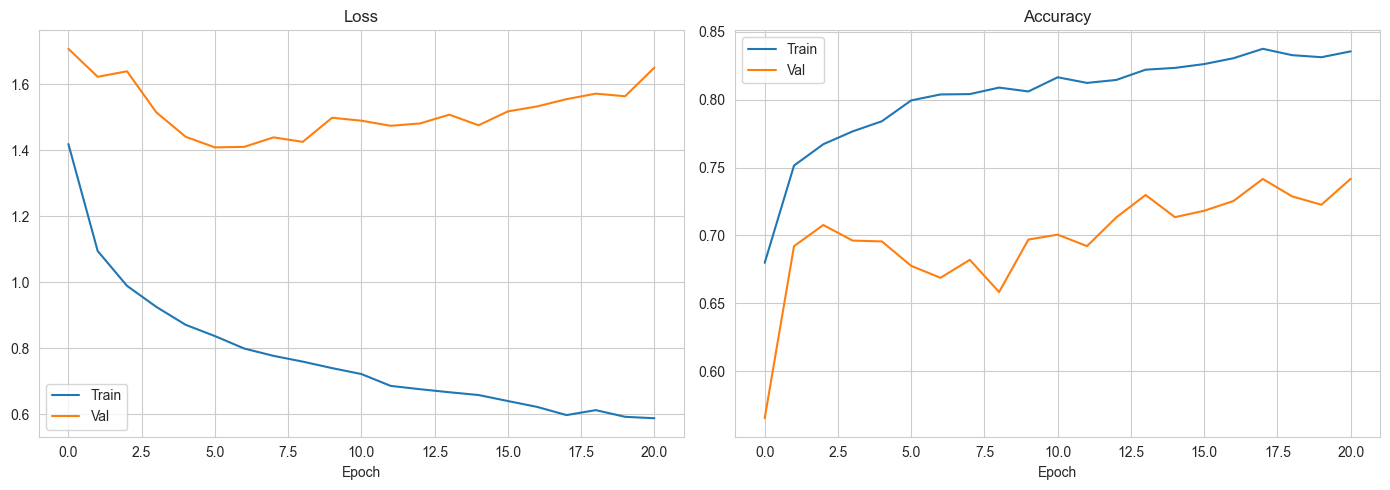

Trained for 21 epochs


In [11]:
print("Training TCN (reduced features)...")
history = model.fit(
    X_train_seg, y_train_seg,
    epochs=CONFIG.tcn_epochs,
    batch_size=CONFIG.tcn_batch_size,
    validation_data=(X_val_seg, y_val_seg),
    callbacks=[
        EarlyStopping('val_loss', patience=CONFIG.tcn_patience, restore_best_weights=True),
        ReduceLROnPlateau('val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train'); ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'], label='Train'); ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"Trained for {len(history.history['loss'])} epochs")

## 12. Evaluate on Test Sessions

In [12]:
def predict_session_tcn(model, session, seg_len, overlap):
    """Predict on a full session by stitching overlapping segments."""
    X = session['X']
    pred_sum = np.zeros(len(X))
    pred_cnt = np.zeros(len(X))
    stride = seg_len - overlap
    for i in range((len(X) - seg_len) // stride + 1):
        start = i * stride
        end = start + seg_len
        if end <= len(X):
            pred = model.predict(X[start:end].reshape(1, seg_len, -1), verbose=0)[0, :, 0]
            pred_sum[start:end] += pred
            pred_cnt[start:end] += 1
    if pred_cnt[-1] == 0 and len(X) >= seg_len:
        start = len(X) - seg_len
        pred = model.predict(X[start:].reshape(1, seg_len, -1), verbose=0)[0, :, 0]
        pred_sum[start:] += pred
        pred_cnt[start:] += 1
    return np.divide(pred_sum, pred_cnt, where=pred_cnt > 0)

print("Evaluating on test sessions...\n")
test_results = []
for session_info in test_sessions_data:
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']
    y_pred_proba = predict_session_tcn(model, session_info, CONFIG.segment_length, CONFIG.segment_overlap)
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1
    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)
    metrics.update({'session': session_info['session'], 'athlete': session_info['athlete'],
                    'y_true': y_true, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba, 'df': session_info['df']})
    test_results.append(metrics)
    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

avg = {k: np.mean([r[k] for r in test_results]) for k in ['f_beta', 'precision', 'recall', 'mean_error_sec']}
print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg['f_beta']:.3f}")
print(f"  Precision: {avg['precision']:.3f}")
print(f"  Recall:    {avg['recall']:.3f}")
print(f"  Avg Error: {avg['mean_error_sec']:.1f} seconds")
print("="*70)

Evaluating on test sessions...

Athlete12    | 13983533934_Technik__30er     
   F_beta(2:1): 0.545 | P: 0.545 | R: 0.545 | Error: 22.1s
   Intervals: 11/11

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 0.333 | P: 0.333 | R: 0.333 | Error: 341.0s
   Intervals: 3/3

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.909 | P: 0.909 | R: 0.909 | Error: 4.5s
   Intervals: 11/11

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.667 | P: 0.667 | R: 0.667 | Error: 29.2s
   Intervals: 9/9

Athlete12    | 12069656901_Schwitzen_im_Sitze
   F_beta(2:1): 0.571 | P: 0.571 | R: 0.571 | Error: 28.1s
   Intervals: 7/7

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.727 | P: 0.727 | R: 0.727 | Error: 34.5s
   Intervals: 11/11

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 0.750 | P: 0.750 | R: 0.750 | Error: 8.3s
   Intervals: 12/12

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.700 | P: 0.700 | R: 0.700 | E

## 13. Visualize All Test Sessions

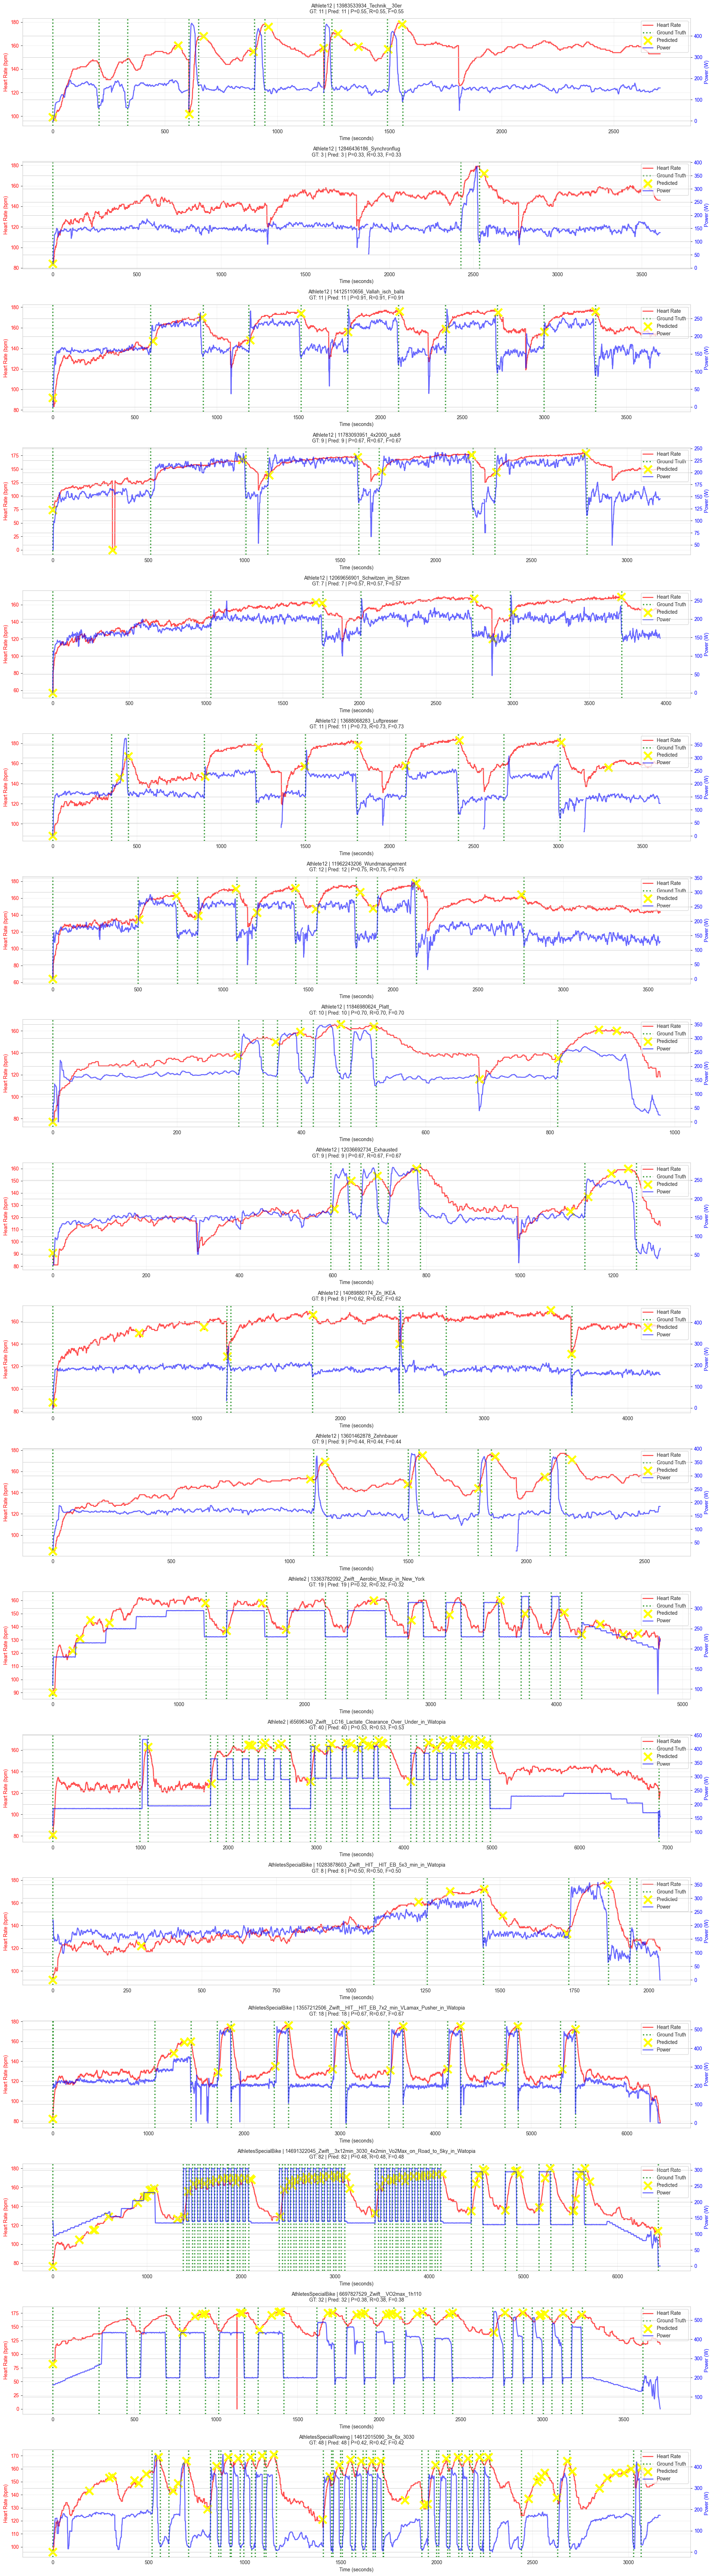

In [13]:
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))
if n_sessions == 1: axes = [axes]
for idx, result in enumerate(test_results):
    df = result['df']
    hr_values = df['heart_rate'].values
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)
    if 'power' in df.columns:
        ax2.plot(df['power'].values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
    gt_cps = np.where(result['y_true'] == 1)[0]
    pred_cps = np.where(result['y_pred'] == 1)[0]
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5, alpha=0.8, zorder=4,
                       label='Ground Truth' if cp == gt_cps[0] else '')
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow', linewidths=4, zorder=5,
                       label='Predicted' if cp == pred_cps[0] else '')
    ax1.set_title(f"{result['athlete']} | {result['session']}\nGT: {result['n_true']} | Pred: {result['n_pred']} | "
                  f"P={result['precision']:.2f}, R={result['recall']:.2f}, F={result['f_beta']:.2f}", fontsize=10, pad=10)
    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red'); ax1.grid(True, alpha=0.3)
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')
plt.tight_layout(); plt.show()

## 14. Summary Statistics

Results: 18 test sessions
  rowing: 12 sessions
  biking: 6 sessions


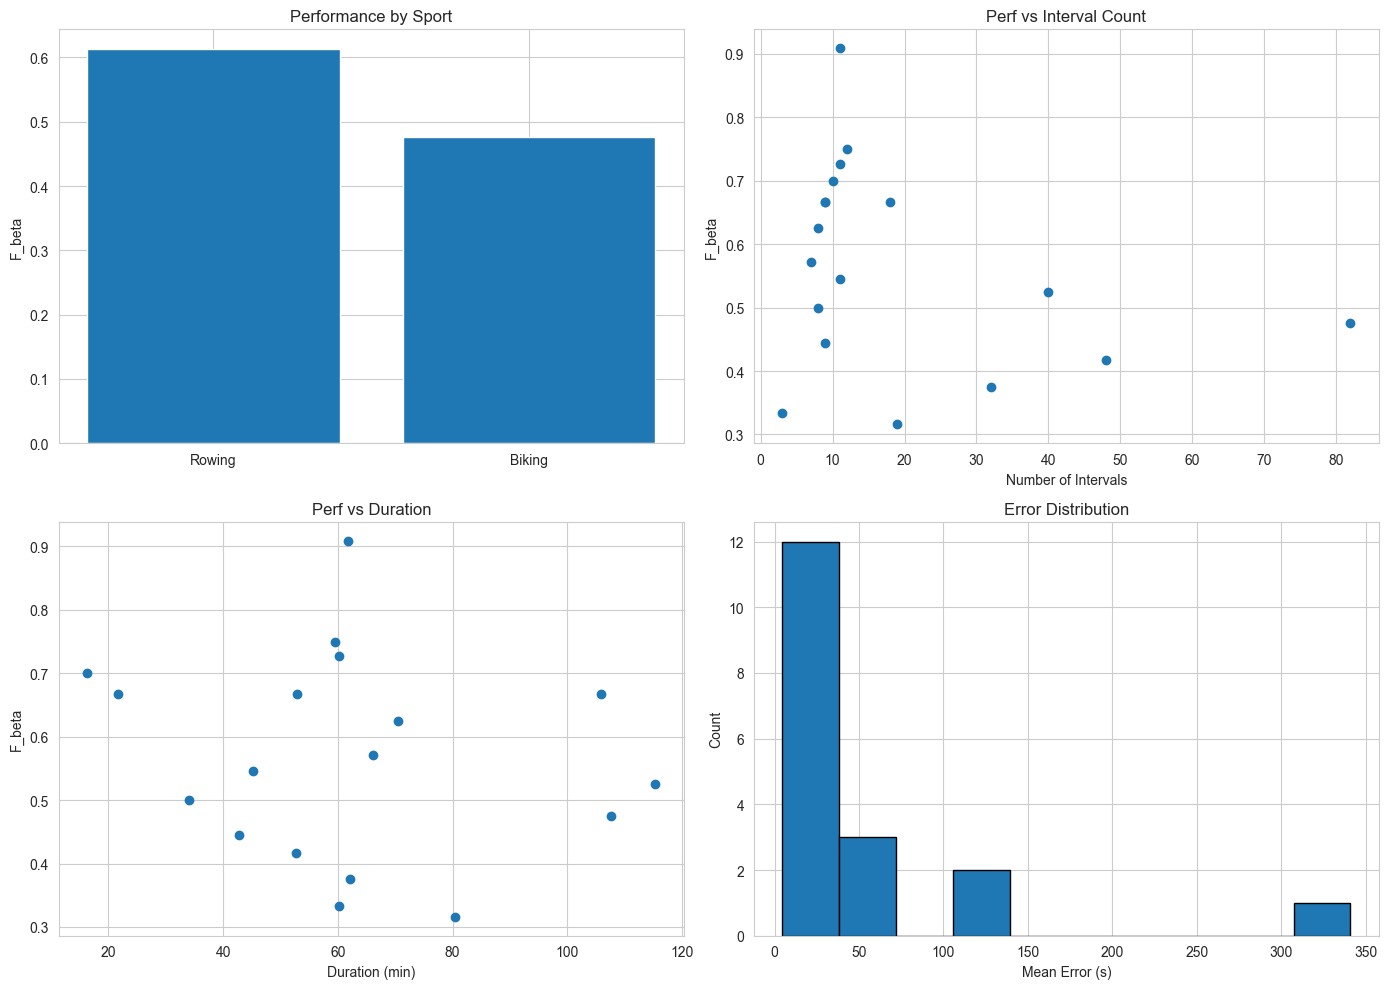

In [14]:
athlete_sport_mapping = {k: v['sport'] for k, v in athletes.items()}
df_results = pd.DataFrame([{
    'athlete': r['athlete'], 'session': r['session'], 'n_intervals': r['n_true'], 'n_pred': r['n_pred'],
    'f_beta': r['f_beta'], 'precision': r['precision'], 'recall': r['recall'],
    'mean_error_sec': r['mean_error_sec'], 'duration_min': len(r['y_true']) / 60,
    'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
} for r in test_results])

print(f"Results: {len(df_results)} test sessions")
for sport, count in df_results['sport'].value_counts().items():
    print(f"  {sport}: {count} sessions")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].bar(['Rowing','Biking'], [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
              df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0,0].set_ylabel('F_beta'); axes[0,0].set_title('Performance by Sport')
axes[0,1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0,1].set_xlabel('Number of Intervals'); axes[0,1].set_ylabel('F_beta'); axes[0,1].set_title('Perf vs Interval Count')
axes[1,0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1,0].set_xlabel('Duration (min)'); axes[1,0].set_ylabel('F_beta'); axes[1,0].set_title('Perf vs Duration')
axes[1,1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1,1].set_xlabel('Mean Error (s)'); axes[1,1].set_ylabel('Count'); axes[1,1].set_title('Error Distribution')
plt.tight_layout(); plt.show()

## 15. Save Results

In [15]:
import pickle
with open('results/tcn_dilated_reduced_results.pkl', 'wb') as f:
    pickle.dump({'model_name': 'TCN_Dilated_ReducedFeatures', 'results': test_results}, f)
print(f"Saved {len(test_results)} TCN Dilated (Reduced Features) results")

Saved 18 TCN Dilated (Reduced Features) results
